In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import sys
from sklearn.model_selection import train_test_split
import torch

import itertools
from itertools import cycle
import torch.nn.functional as F
import time
import scipy.io 
from scipy.io import savemat


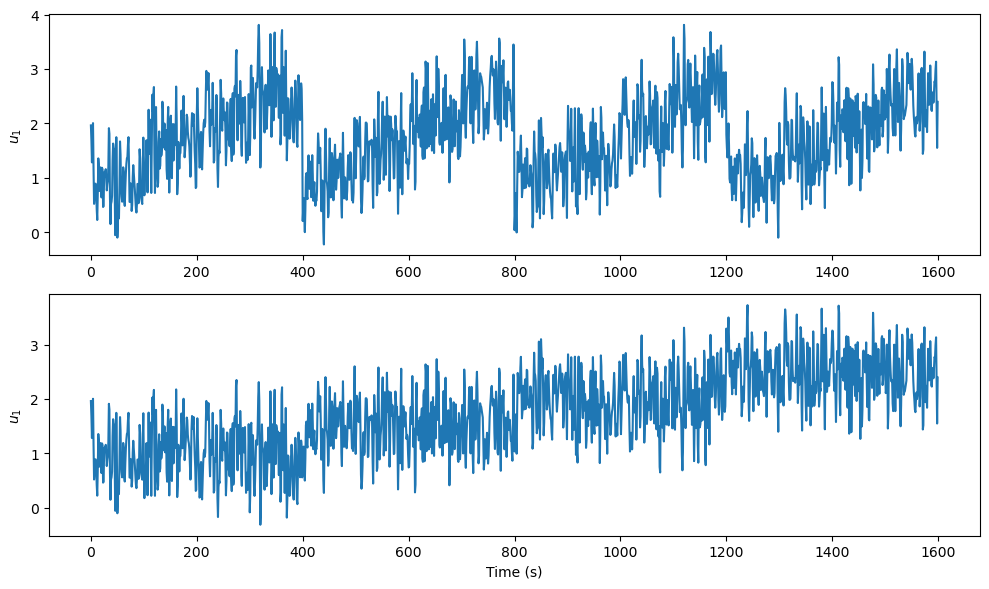

In [23]:
crest_factor = lambda uk: np.max(np.abs(uk))/np.sqrt(np.mean(uk**2))
duplicate = lambda uk,n: np.concatenate([uk]*n)
 

def multisine(N_points_per_period, N_periods=1, pmin=1, pmax=21, prule=lambda p: p%2==1 and p%6!=1, par=None,
            n_crest_factor_optim=1, seed=None):
    '''A multi-sine geneator with only odd frequences and random phases.
 
    Paramters
    ---------
    N_points_per_period : int
    N_periods : int
    pmin : int
        The lowest number of sin periods allowed in the signal
    pmax : int
        The hightest number of sin periods allowed in the signal
    prule : lambda function
        A function which is true if the p should be allowed. Often used to only select odd frequences
        By default it will allow p%2==1 and p%6!=1 as: [3, 5, 9, 11, 15, 17, 21, 23, 27, 29, 33, 35, 39, 41, 45...]
    par : list of ints like
        Manual list of sin periods in the signal (note: overwrites prule)
    n_crest_factor_optim : int
        n random trails to mimize the crest factor (max(y)/std(y))
    seed : int, None or RandomState
        the random seed used for the generation
   
 
    fmax = pmax/(N_points_per_period*sample time)
    '''
    if isinstance(seed,int) or seed is None:
        rng = np.random.RandomState(seed)
    else:
        rng = seed
    assert isinstance(rng, np.random.mtrand.RandomState)
 
    assert pmax<N_points_per_period//2
    #crest factor optim:
    if n_crest_factor_optim>1:
        ybest = None
        crest_best = float('inf')
        for i in range(n_crest_factor_optim):
            seedi = None if seed is None else seed + i
            uk = multisine(N_points_per_period, N_periods=1, pmax=pmax, pmin=pmin, prule=prule, n_crest_factor_optim=1, seed=seedi)
            crest = crest_factor(uk)
            if crest<crest_best:
                ybest = uk
                crest_best = crest
        return duplicate(ybest, N_periods)
 
    N = N_points_per_period
 
    uf = np.zeros((N,),dtype=complex)
    for p in range(pmin,pmax) if par==None else par:
        if par==None and not prule(p):
            continue
        uf[p] = np.exp(1j*rng.uniform(0,np.pi*2))
        uf[N-p] = np.conjugate(uf[p])
 
    uk = np.real(np.fft.ifft(uf/2)*N)
    uk /= np.std(uk)
 
    return duplicate(uk, N_periods)


# u1_data1 =  np.tile([1.637], (500, 1))
# u1_data2 =  np.tile([1.112], (500, 1))
# u1_data3 =  np.tile([2.201], (500, 1))
# u1_data4 =  np.tile([1.528], (1000, 1))

u1_data1 =  np.tile([1.000], (100, 1))
u1_data2 =  np.tile([1.500], (100, 1))
u1_data3 =  np.tile([2.000], (100, 1))
u1_data4 =  np.tile([2.500], (100, 1))

u1_data_all = np.concatenate((u1_data1, u1_data2, u1_data3, u1_data4), axis=0)
u1_data_all = np.concatenate((u1_data_all, u1_data_all, u1_data_all, u1_data_all), axis=0)

u2_data1 =  np.tile([1.000], (400, 1))
u2_data2 =  np.tile([1.500], (400, 1))
u2_data3 =  np.tile([2.000], (400, 1))
u2_data4 =  np.tile([2.500], (400, 1))
u2_data_all = np.concatenate((u2_data1, u2_data2, u2_data3, u2_data4), axis=0)




u_data_1_additional = 0.5*multisine(N_points_per_period=1600, N_periods=1, pmin=1, pmax=500, n_crest_factor_optim=100,seed=42)
u_data_2_additional = 0.5*multisine(N_points_per_period=1600, N_periods=1, pmin=1, pmax=500, n_crest_factor_optim=100,seed=36)

u1_data = u1_data_all + u_data_1_additional.reshape(-1, 1)
u2_data = u2_data_all + u_data_2_additional.reshape(-1, 1)


# Plot the solution
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(u1_data)
plt.ylabel('$u_1$')
plt.subplot(2, 1, 2)
plt.plot(u2_data)
plt.ylabel('$u_1$')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

C:\Users\Michiel\AppData\Local\Temp\ipykernel_40384\1018094700.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u1 = float(u1_data[i])
C:\Users\Michiel\AppData\Local\Temp\ipykernel_40384\1018094700.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u2 = float(u2_data[i])


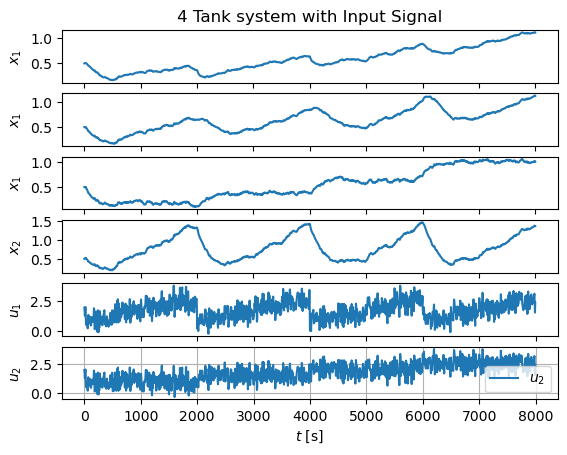

u_data.shape = (1600, 2)
x.shape = (1601, 4)


In [24]:
# Model parameters
a1, a2, a3, a4 = 1.31e-4, 1.51e-4, 9.27e-5, 8.82e-5
gamma_a, gamma_b = 0.3, 0.4
g, Sc = 9.81, 0.06

params = {'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4, 'gamma_a': gamma_a, 'gamma_b': gamma_b, 'g': g, 'Sc': Sc}

# Define the Van der Pol oscillator
def four_tank(t, x, u1, u2, params):
    x1, x2, x3, x4 = x
    a1, a2, a3, a4 = params['a1'], params['a2'], params['a3'], params['a4']
    Sc, gamma_a, gamma_b = params['Sc'], params['gamma_a'], params['gamma_b']
    g = params['g']
    dx1 = (-a1 / Sc) * np.sqrt(max(0, 2 * g * x1)) + (a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + gamma_a / (3600 * Sc) * u1
    dx2 = (-a2 / Sc) * np.sqrt(max(0, 2 * g * x2)) + (a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + gamma_b / (3600 * Sc) * u2
    dx3 = (-a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + (1 - gamma_b) / (3600 * Sc) * u2
    dx4 = (-a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + (1 - gamma_a) / (3600 * Sc) * u1
    return [dx1, dx2, dx3, dx4]

# Parameters
x0 = np.array([0.5, 0.5, 0.5, 0.5])  # Initial conditions: [x0, dx0]
Ts = 5
t_vec = [0]
x = [x0]

# Main loop
for i in range(len(u1_data)):
    # print(f"{i+1}/{len(u_data)}")
    u1 = float(u1_data[i])
    u2 = float(u2_data[i])
    # print(u)
    # print(u.shape)
    # Solve over one time step
    # sol_ivp = solve_ivp(lambda t, x: four_tank(t, x, u_mpc[0], u_mpc[1], params), [0, Ts], x_current)
    # x_next = sol_ivp.y[:, -1]
    sol = solve_ivp(lambda t, y: four_tank(t, y, u1, u2, params),[0, Ts], x0, method='RK45')

    # Take the last value as the new initial condition
    x0 = sol.y[:, -1]
    x.append(x0)  # store state
    t_vec.append((i+1) * Ts)  # store time

# Convert list to numpy array for easier plotting
x = np.array(x)
t_vec = np.array(t_vec)

# Plotting
# Plotting
plt.subplot(6,1,1)
plt.plot(t_vec, x[:, 0], label='$x_1$')
plt.title('4 Tank system with Input Signal')
plt.ylabel('$x_1$')
plt.subplot(6,1,2)
plt.plot(t_vec, x[:, 1], label='$x_1$')
plt.ylabel('$x_1$')
plt.subplot(6,1,3)
plt.plot(t_vec, x[:, 2], label='$x_1$')
plt.ylabel('$x_1$')
plt.subplot(6,1,4)
plt.plot(t_vec, x[:, 3], label='$x_2$')
plt.ylabel('$x_2$')
plt.subplot(6,1,5)
plt.plot(t_vec[0:len(u1_data)], u1_data, label='$u_1$')
plt.ylabel('$u_1$')
plt.subplot(6,1,6)
plt.plot(t_vec[0:len(u2_data)], u2_data, label='$u_2$')
plt.ylabel('$u_2$')
plt.xlabel('$t$ [s]')
plt.legend()
plt.grid()
plt.show()


u_data = np.hstack((u1_data,u2_data))

print(f'u_data.shape = {u_data.shape}')
print(f'x.shape = {x.shape}')



In [32]:
u_data[100:110,:]


array([[1.35936744, 0.85936744],
       [0.67841489, 0.17841489],
       [1.0714107 , 0.5714107 ],
       [1.24830547, 0.74830547],
       [1.26318949, 0.76318949],
       [1.68982456, 1.18982456],
       [1.39379312, 0.89379312],
       [0.73154909, 0.23154909],
       [1.44056503, 0.94056503],
       [2.25047492, 1.75047492]])

In [38]:
u2_data[100:110]

array([[0.85936744],
       [0.17841489],
       [0.5714107 ],
       [0.74830547],
       [0.76318949],
       [1.18982456],
       [0.89379312],
       [0.23154909],
       [0.94056503],
       [1.75047492]])

In [25]:
np.save('uvec_test.npy', u_data )
np.save('xvec_test.npy',x)

In [100]:
U = []
X0 = []
Y = []
N = 20

# Assuming u_data is a 1D array of shape (T,)
# Assuming x is a 2D array of shape (2, T)
# N is the window size

T = len(u_data)

sys.exit

for i in range(T - N):
    # Input sequence of length N

    # Output trajectory over N steps (x[0] = first state variable)
    Y_i = []
    U_i = []
    for j in range(N):
        if j == 0:
            Y_i = x[i + j + 1,:]  # x(1, i+j) in MATLAB → x[0, i+j+1] in Python
            U_i = u_data[i + j ,:]  # x(1, i+j) in MATLAB → x[0, i+j+1] in Python
        else:
            Y_i = np.hstack((Y_i,x[i + j + 1,:])) # x(1, i+j) in MATLAB → x[0, i+j+1] in Python
            U_i = np.hstack((U_i,u_data[i + j,:]))  # x(1, i+j) in MATLAB → x[0, i+j+1] in Python

    
    # print(f'Y_i.shape = {Y_i.shape}')
    # print(f'U_i.shape = {U_i.shape}')

    # sys.exit()
    if i == 0:
        Y = Y_i  # x(1, i+j) in MATLAB → x[0, i+j+1] in Python
        U = U_i  # x(1, i+j) in MATLAB → x[0, i+j+1] in Python
    else:
        Y = np.vstack((Y,Y_i)) # x(1, i+j) in MATLAB → x[0, i+j+1] in Python
        U = np.vstack((U,U_i))  # x(1, i+j) in MATLAB → x[0, i+j+1] in Python

    # Initial state at time i
    X0.append(x[i,:])  # shape (2,)

# Convert to numpy arrays
U = np.array(U).T     # shape (N, T-N)
X0 = np.array(X0).T   # shape (2, T-N)
Y = np.array(Y).T     # shape (N, T-N)

# Optional: print shapes
print(f"U.shape = {U.shape}")   # (N, T-N)
print(f"X0.shape = {X0.shape}") # (2, T-N)
print(f"Y.shape = {Y.shape}")   # (N, T-N)



U.shape = (40, 7980)
X0.shape = (4, 7980)
Y.shape = (80, 7980)


In [102]:
# Transpose to shape (samples, features)
U_T = U.T    # shape (1400, 10)
X0_T = X0.T  # shape (1400, 2)
Y_T = Y.T    # shape (1400, 10)

# Now split
# U_train, U_test, X0_train, X0_test, Y_train, Y_test = train_test_split(
#     U_T, X0_T, Y_T, test_size=0.2855, random_state=42
# )

U_train = U_T[0:7500,:]
U_test = U_T[7500:,:]
X0_train = X0_T[0:7500,:]
X0_test = X0_T[7500:,:]
Y_train = Y_T[0:7500,:]
Y_test = Y_T[7500:,:]

# Optionally transpose back if needed
U_train = U_train
U_test = U_test
X0_train = X0_train
X0_test = X0_test
Y_train = Y_train
Y_test = Y_test

# Check shapes
print("Shapes after split:")
print(f"U_train: {U_train.shape}, U_test: {U_test.shape}")
print(f"X0_train: {X0_train.shape}, X0_test: {X0_test.shape}")
print(f"Y_train: {Y_train.shape}, Y_test: {Y_test.shape}")



Shapes after split:
U_train: (7500, 40), U_test: (480, 40)
X0_train: (7500, 4), X0_test: (480, 4)
Y_train: (7500, 80), Y_test: (480, 80)


In [103]:
device = torch.device("cpu:0")

trunk_input_train = torch.tensor(X0_train, dtype=torch.float32).to(device)
branch_input_train = torch.tensor(U_train, dtype=torch.float32).to(device)
output_train = torch.squeeze(torch.tensor(Y_train, dtype=torch.float32).to(device))

trunk_input_val = torch.tensor(X0_test, dtype=torch.float32).to(device)
branch_input_val = torch.tensor(U_test, dtype=torch.float32).to(device)
output_val = torch.squeeze(torch.tensor(Y_test, dtype=torch.float32).to(device))



B_train = len(trunk_input_train[:,0])
B_val = len(trunk_input_val[:,0])
nx = len(trunk_input_train[0,:])
Nnu = len(branch_input_train[0,:])
Nny = len(output_train[0,:])

# print(Nnu)
# print(Nny)
# print(nx)


# sys.exit()


def train(idx,neuron,layer,ld,loss_val_i):
    niter = 40001

    branch = models.MLP(
        layers=[Nnu] + [neuron] * layer + [ld*Nny],
        activation=F.tanh,
    ).to(device)

    trunk = models.MLP(layers=[nx] + [neuron] * layer + [ld], activation=F.tanh).to(device)

    # print(trunk)
    # sys.exit()

    # Adding L2 regularization (weight decay) to the optimizer
    optimizer = torch.optim.AdamW(
        list(branch.parameters()) + list(trunk.parameters()), 
        lr=1e-3,
        weight_decay=1e-4  # L2 regularization (weight decay)
    )

    # Add a learning rate scheduler that reduces the learning rate by a factor of 0.1 every 1000 iterations
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.5)

    # training
    train_loss_hist = []
    val_loss_hist = []
    t0 = time.time()
    for i in range(niter):

        def train_step():
            optimizer.zero_grad()            
            b_out = branch(branch_input_train)
            t_out = trunk(trunk_input_train)
            # print(b_out.shape)
            b_out = b_out.reshape(B_train, Nny, ld)
            u_pred = torch.einsum("bij,bj->bi", b_out, t_out)
            # print(branch)
            # print(output_train.shape)
            # sys.exit()
            loss = torch.mean((u_pred - output_train) ** 2) / torch.mean((output_train) ** 2)
            loss.backward()
            optimizer.step()
            return loss
        

        def validation_step():
             with torch.no_grad():               
                b_out = branch(branch_input_val)
                t_out = trunk(trunk_input_val)
                b_out = b_out.reshape(B_val, Nny, ld)
                u_pred = torch.einsum("bij,bj->bi", b_out, t_out)
                # print(u_pred.shape)
                # print(output_val.shape)
                # sys.exit()
                loss = torch.mean((u_pred - output_val) ** 2) / torch.mean((output_val) ** 2)
                return loss

        loss_train = train_step()
        loss_val = validation_step()
        l_train = loss_train.detach().cpu().numpy()
        l_val = loss_val.detach().cpu().numpy()


        train_loss_hist.append(l_train)
        val_loss_hist.append(l_val)

        # Get the current learning rate from the optimizer
        current_lr = optimizer.param_groups[0]['lr']

        # Round the learning rate to 5 decimal places
        current_lr = round(current_lr, 5)
        
        if i % 10 == 0:
            print(
                "index: ",
                idx,
                "/ 27",
                "Epoch: ",
                i + 1,
                "Learning rate: ",
                current_lr,
                "Train loss",
                l_train,
                "Val loss",
                l_val,
                flush=True,
            )
        if i % 1000 == 0 and loss_val_i >= l_val:
            loss_val_i = l_val
            l_indx_i = i
            torch.save(branch, "data_mimo/kan_mlp_branch_idx_{}".format(str(int(idx))))
            torch.save(trunk, "data_mimo/kan_mlp_trunk_idx_{}".format(str(int(idx))))

        # Step the scheduler at the end of each iteration
        scheduler.step()
        
    t1 = time.time()
    print("Total time: ", t1 - t0, flush=True)
    np.save("data_mimo/train_loss.npy", train_loss_hist, allow_pickle=True)
    np.save("data_mimo/val_loss.npy", val_loss_hist, allow_pickle=True)

    # torch.save(branch, "data_mimo/mlp_branch_idx_{}".format(str(int(idx))))
    # torch.save(trunk, "data_mimo/mlp_trunk_idx_{}".format(str(int(idx))))

    return np.array(train_loss_hist), np.array(val_loss_hist), l_indx_i, loss_val_i


# start of the ablation study 
ablation_results = [] 


ld_list = [20] # Neurons in output hidden layer 
neuron_list = [20] # Neurons per hidden layer
layer_list = [2] # number of hidden layers

# ld_list = [10]
# neuron_list = [20]
# layer_list = [2]


combinations = itertools.product(ld_list,neuron_list,layer_list)


idx_i = 0

# Looping through the range of indices (1 to idx_total-1 in this case, but you can extend it)
for ld_i, neuron_i, layer_i in combinations:
    idx_i += 1
    # Call the train function with the current index
    train_loss_hist_i, val_loss_hist_i, l_indx_opt, loss_val_opt   = train(idx=idx_i,ld=ld_i,neuron=neuron_i,layer=layer_i,loss_val_i=float('inf'))
    
    # Create a dictionary to store the results
    results = {
        'idx': idx_i,
        'neurons output layer': ld_i,
        'neurons hidden per layer': neuron_i,
        'hidden layers': layer_i,
        'training loss': train_loss_hist_i,
        'validation loss': val_loss_hist_i
    }
    
    # Append the results to the ablation_results list
    ablation_results.append(results)

# Convert the list of dictionaries into a dictionary of lists
ablation_results_dict = {
    'idx': [entry['idx'] for entry in ablation_results],
    'neurons_output_layer': [entry['neurons output layer'] for entry in ablation_results],
    'neurons_hidden_per_layer': [entry['neurons hidden per layer'] for entry in ablation_results],
    'hidden_layers': [entry['hidden layers'] for entry in ablation_results],
}

ablation_results_dict['training_loss'] = np.array([entry['training loss'] for entry in ablation_results])
ablation_results_dict['validation_loss'] = np.array([entry['validation loss'] for entry in ablation_results])

# Save the data as a .mat file
scipy.io.savemat('data_mimo/ablation_results.mat', ablation_results_dict)


# Print the results to verify
print("End main.")
print(ablation_results)
print('result 1:')
print(ablation_results[0]['training loss'])
print('result 2:')
print(ablation_results[0]['training loss'])

l_indx_opt, loss_val_opt
print(f'l_indx_opt: {l_indx_opt}')
print(f'loss_val_opt: {loss_val_opt}')




index:  1 / 27 Epoch:  1 Learning rate:  0.001 Train loss 1.2542995 Val loss 1.072131
index:  1 / 27 Epoch:  11 Learning rate:  0.001 Train loss 0.5636646 Val loss 0.5526218
index:  1 / 27 Epoch:  21 Learning rate:  0.001 Train loss 0.2225195 Val loss 0.12208746
index:  1 / 27 Epoch:  31 Learning rate:  0.001 Train loss 0.13183174 Val loss 0.14816564
index:  1 / 27 Epoch:  41 Learning rate:  0.001 Train loss 0.097631 Val loss 0.07917825
index:  1 / 27 Epoch:  51 Learning rate:  0.001 Train loss 0.063746296 Val loss 0.068287395
index:  1 / 27 Epoch:  61 Learning rate:  0.001 Train loss 0.040797304 Val loss 0.050296176
index:  1 / 27 Epoch:  71 Learning rate:  0.001 Train loss 0.027043806 Val loss 0.033874277
index:  1 / 27 Epoch:  81 Learning rate:  0.001 Train loss 0.019436019 Val loss 0.02652471
index:  1 / 27 Epoch:  91 Learning rate:  0.001 Train loss 0.014540185 Val loss 0.020628404
index:  1 / 27 Epoch:  101 Learning rate:  0.001 Train loss 0.011592189 Val loss 0.01595047
index:  

Text(0.5, 1.0, 'Training and validation loss')

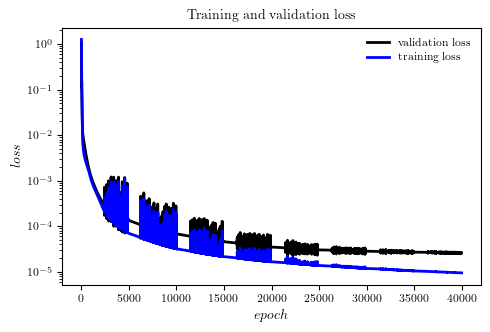

In [104]:
from plotting import newfig, savefig
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

# Load the loss data
val_loss = np.load("data_mimo/val_loss.npy")
train_loss = np.load("data_mimo/train_loss.npy")

####### Row 0: u(t,x) ##################    
gs0 = gridspec.GridSpec(1,1)
#gs0.update(top=1-0.06, bottom=1-1/3, left=0.15, right=0.85, wspace=0)
ax = plt.subplot(gs0[:, :])
ax.semilogy(val_loss, '-k', lw=2.0, label="validation loss")
ax.semilogy(train_loss, '-b', lw=2.0, label="training loss")
ax.set_xlabel('$epoch$')
ax.set_ylabel('$loss$')
ax.legend(frameon=False, loc = 'best')
ax.set_title('Training and validation loss', fontsize = 10)

In [105]:
import casadi as ca

branch = torch.load("data_mimo/kan_mlp_branch_idx_1", weights_only=False)
trunk = torch.load("data_mimo/kan_mlp_trunk_idx_1", weights_only=False)

# W0_np = branch.linears[0].weight.detach().cpu().numpy()
# b0_np = branch.linears[0].bias.detach().cpu().numpy()

# print(f'len(branch.linears) = {len(branch.linears)}')
x0_test = X0_test[0,:]

# print(x0_test)
# print(x0_test.shape)

# sys.exit 


def NN(u, Network, sigma):
    """Evaluate the neural network with input u."""
    y = u
    L = len(Network.linears)
    for i in range(L - 1):
        W = ca.DM(Network.linears[i].weight.detach().cpu().numpy())
        b = ca.DM(Network.linears[i].bias.detach().cpu().numpy())
        y = sigma(W @ y + b)  # @ is matrix multiplication
    
    W = ca.DM(Network.linears[-1].weight.detach().cpu().numpy())
    b = ca.DM(Network.linears[-1].bias.detach().cpu().numpy())
    y = W @ y + b
    return y


u_test = U_test[0,:]
# print(u_test.shape)

print(f'u_test.shape = {u_test.shape}')
print(f'x0_test.shape = {x0_test.shape}')

Ytest = NN(u_test, branch, np.tanh)
Ytest2 = NN(x0_test, trunk, np.tanh)
# print(Ytest)
# print(Ytest.shape)
# print(Ytest2)
# print(Ytest2.shape)

u_test.shape = (40,)
x0_test.shape = (4,)


Step 0
Step 1
Step 2
Step 3
Step 4
Step 5
Step 6
Step 7
Step 8
Step 9
Step 10
Step 11
Step 12
Step 13
Step 14
Step 15
Step 16
Step 17
Step 18
Step 19
Step 20
Step 21
Step 22
Step 23
Step 24
Step 25
Step 26
Step 27
Step 28
Step 29
Step 30
Step 31
Step 32
Step 33
Step 34
Step 35
Step 36
Step 37
Step 38
Step 39
Step 40
Step 41
Step 42
Step 43
Step 44
Step 45
Step 46
Step 47
Step 48
Step 49
Step 50
Step 51
Step 52
Step 53
Step 54
Step 55
Step 56
Step 57
Step 58
Step 59
Step 60
Step 61
Step 62
Step 63
Step 64
Step 65
Step 66
Step 67
Step 68
Step 69
Step 70
Step 71
Step 72
Step 73
Step 74
Step 75
Step 76
Step 77
Step 78
Step 79
Step 80
Step 81
Step 82
Step 83
Step 84
Step 85
Step 86
Step 87
Step 88
Step 89
Step 90
Step 91
Step 92
Step 93
Step 94
Step 95
Step 96
Step 97
Step 98
Step 99
Step 100
Step 101
Step 102
Step 103
Step 104
Step 105
Step 106
Step 107
Step 108
Step 109
Step 110
Step 111
Step 112
Step 113
Step 114
Step 115
Step 116
Step 117
Step 118
Step 119
Step 120
Step 121
Step 122
Ste

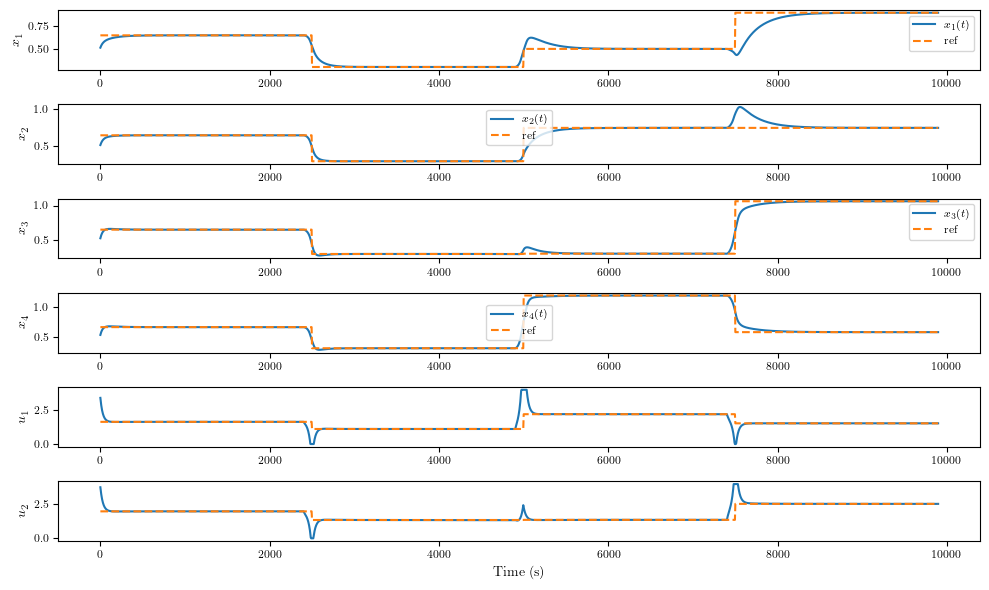

In [93]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Reference trajectories
ref1 = np.tile([0.650, 0.650, 0.652, 0.664], (500, 1))
ref2 = np.tile([0.300, 0.300, 0.301, 0.306], (500, 1))
ref3 = np.tile([0.500, 0.750, 0.305, 1.200], (500, 1))
ref4 = np.tile([0.900, 0.750, 1.062, 0.579], (500, 1))

uref1 = np.tile([1.637, 1.988], (500, 1))
uref2 = np.tile([1.112, 1.351], (500, 1))
uref3 = np.tile([2.201, 1.361], (500, 1))
uref4 = np.tile([1.528, 2.539], (500, 1))

xref_traj = np.concatenate((ref1, ref2, ref3, ref4), axis=0)
uref_traj = np.concatenate((uref1, uref2, uref3, uref4), axis=0)

# Model parameters
a1, a2, a3, a4 = 1.31e-4, 1.51e-4, 9.27e-5, 8.82e-5
gamma_a, gamma_b = 0.3, 0.4
g, Sc = 9.81, 0.06

params = {'a1': a1, 'a2': a2, 'a3': a3, 'a4': a4, 'gamma_a': gamma_a, 'gamma_b': gamma_b, 'g': g, 'Sc': Sc}

# Dynamics function for simulation
def four_tank(t, x, u1, u2, params):
    x1, x2, x3, x4 = x
    a1, a2, a3, a4 = params['a1'], params['a2'], params['a3'], params['a4']
    Sc, gamma_a, gamma_b = params['Sc'], params['gamma_a'], params['gamma_b']
    g = params['g']
    dx1 = (-a1 / Sc) * np.sqrt(max(0, 2 * g * x1)) + (a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + gamma_a / (3600 * Sc) * u1
    dx2 = (-a2 / Sc) * np.sqrt(max(0, 2 * g * x2)) + (a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + gamma_b / (3600 * Sc) * u2
    dx3 = (-a3 / Sc) * np.sqrt(max(0, 2 * g * x3)) + (1 - gamma_b) / (3600 * Sc) * u2
    dx4 = (-a4 / Sc) * np.sqrt(max(0, 2 * g * x4)) + (1 - gamma_a) / (3600 * Sc) * u1
    return [dx1, dx2, dx3, dx4]

# CasADi dynamics
def casadi_dynamics(x, u):
    h1, h2, h3, h4 = x[0], x[1], x[2], x[3]
    h1_dot = -a1/Sc*ca.sqrt(2*g*ca.fmax(h1, 0)) + a3/Sc*ca.sqrt(2*g*ca.fmax(h3, 0)) + gamma_a/(3600*Sc)*u[0]
    h2_dot = -a2/Sc*ca.sqrt(2*g*ca.fmax(h2, 0)) + a4/Sc*ca.sqrt(2*g*ca.fmax(h4, 0)) + gamma_b/(3600*Sc)*u[1]
    h3_dot = -a3/Sc*ca.sqrt(2*g*ca.fmax(h3, 0)) + (1-gamma_b)/(3600*Sc)*u[1]
    h4_dot = -a4/Sc*ca.sqrt(2*g*ca.fmax(h4, 0)) + (1-gamma_a)/(3600*Sc)*u[0]
    return ca.vertcat(h1_dot, h2_dot, h3_dot, h4_dot)

# MPC setup
Ts = 5
N = 20
nx, nu = 4, 2
Q = np.diag([1, 1, 1, 1])
R = np.diag([0.01, 0.01])

opti = ca.Opti()
X = opti.variable(nx, N+1)
U = opti.variable(nu, N+1)
x0 = opti.parameter(nx)
ref = opti.parameter(nx, N+1)
uref = opti.parameter(nu, N+1)

cost = 0
for k in range(N):
    x_err = X[:,k] - ref[:,k]
    u_err = U[:,k] - uref[:,k]
    cost += ca.mtimes([x_err.T, Q, x_err]) + ca.mtimes([u_err.T, R, u_err])
    x_next = X[:,k] + Ts * casadi_dynamics(X[:,k], U[:,k])
    opti.subject_to(X[:,k+1] == x_next)

# Constraints
opti.subject_to(X[:,0] == x0)
opti.subject_to(opti.bounded(0, X, np.inf))  # ensure states are non-negative
opti.subject_to(opti.bounded(0, U, 4.0))     # input bounds
opti.minimize(cost)

# Solver
opti.solver('ipopt', {
    'ipopt.print_level': 0,
    'print_time': 0,
    'ipopt.tol': 1e-6
})

# Simulation loop
x_vals, u_vals = [], []
x_current = np.array([0.5, 0.5, 0.5, 0.5])

for i in range(len(xref_traj) - N):
    print(f"Step {i}")
    REF = xref_traj[i:i+N+1,:].T
    UREF = uref_traj[i:i+N+1,:].T

    opti.set_value(x0, x_current)
    opti.set_value(ref, REF)
    opti.set_value(uref, UREF)

    # Set initial guesses
    opti.set_initial(X, np.tile(x_current.reshape(-1,1), (1, N+1)))
    last_u = u_vals[-1] if u_vals else np.array([1.0, 1.0])
    opti.set_initial(U, np.tile(last_u.reshape(-1,1), (1, N+1)))

    try:
        sol = opti.solve()
    except RuntimeError as e:
        print(f"Solver failed at step {i}: {e}")
        break

    u_mpc = sol.value(U[:, 0])
    sol_ivp = solve_ivp(lambda t, x: four_tank(t, x, u_mpc[0], u_mpc[1], params), [0, Ts], x_current)
    x_next = sol_ivp.y[:, -1]

    x_vals.append(x_next)
    u_vals.append(u_mpc)
    x_current = x_next

# Convert logs
x_vals = np.array(x_vals)
u_vals = np.array(u_vals)
t_vec = np.arange(len(x_vals)) * Ts

# Plotting
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(6, 1, i+1)
    plt.plot(t_vec, x_vals[:, i], label=f'$x_{i+1}(t)$')
    plt.plot(t_vec, xref_traj[:len(x_vals), i], '--', label='ref')
    plt.ylabel(f'$x_{i+1}$')
    plt.legend()
plt.subplot(6, 1, 5)
plt.plot(t_vec, u_vals[:,0])
plt.plot(t_vec, uref_traj[:len(u_vals), 0], '--', label='ref')
plt.ylabel('$u_1$')
plt.subplot(6, 1, 6)
plt.plot(t_vec, u_vals[:,1])
plt.plot(t_vec, uref_traj[:len(u_vals), 1], '--', label='ref')
plt.ylabel('$u_2$')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


i = 0 / 1980
i = 1 / 1980
i = 2 / 1980
i = 3 / 1980
i = 4 / 1980
i = 5 / 1980
i = 6 / 1980
i = 7 / 1980
i = 8 / 1980
i = 9 / 1980
i = 10 / 1980
i = 11 / 1980
i = 12 / 1980
i = 13 / 1980
i = 14 / 1980
i = 15 / 1980
i = 16 / 1980
i = 17 / 1980
i = 18 / 1980
i = 19 / 1980
i = 20 / 1980
i = 21 / 1980
i = 22 / 1980
i = 23 / 1980
i = 24 / 1980
i = 25 / 1980
i = 26 / 1980
i = 27 / 1980
i = 28 / 1980
i = 29 / 1980
i = 30 / 1980
i = 31 / 1980
i = 32 / 1980
i = 33 / 1980
i = 34 / 1980
i = 35 / 1980
i = 36 / 1980
i = 37 / 1980
i = 38 / 1980
i = 39 / 1980
i = 40 / 1980
i = 41 / 1980
i = 42 / 1980
i = 43 / 1980
i = 44 / 1980
i = 45 / 1980
i = 46 / 1980
i = 47 / 1980
i = 48 / 1980
i = 49 / 1980
i = 50 / 1980
i = 51 / 1980
i = 52 / 1980
i = 53 / 1980
i = 54 / 1980
i = 55 / 1980
i = 56 / 1980
i = 57 / 1980
i = 58 / 1980
i = 59 / 1980
i = 60 / 1980
i = 61 / 1980
i = 62 / 1980
i = 63 / 1980
i = 64 / 1980
i = 65 / 1980
i = 66 / 1980
i = 67 / 1980
i = 68 / 1980
i = 69 / 1980
i = 70 / 1980
i = 71 / 1980
i 

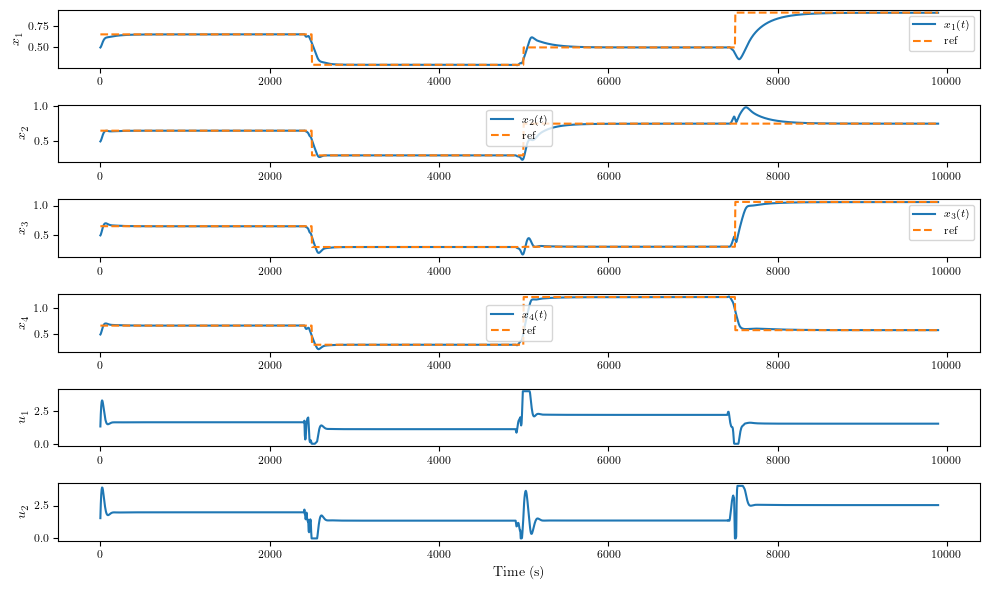

In [ ]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys


branch = torch.load("data_mimo/kan_mlp_branch_idx_1", weights_only=False)
trunk = torch.load("data_mimo/kan_mlp_trunk_idx_1", weights_only=False)


# Define constant pieces
ref1 = np.tile([0.650, 0.650, 0.652, 0.664], (500, 1))
ref2 = np.tile([0.300, 0.300, 0.301, 0.306], (500, 1))
ref3 = np.tile([0.500, 0.750, 0.305, 1.200], (500, 1))
ref4 = np.tile([0.900, 0.750, 1.062, 0.579], (500, 1))

# Concatenate them along the first axis (time steps)
xref_traj = np.concatenate((ref1, ref2, ref3,ref4), axis=0)  # Shape (100, 2)


N = 20  # horizon
ld = 20
nx = 4  # [theta, theta_dot]
ny = 4  # [theta, theta_dot]
nu = 2  # torque

   
# Set up optimization
opti = ca.Opti()
y = opti.variable(ny*N,)
u = opti.variable(nu*N,)
du = opti.variable(nu*N,)
x0 = opti.parameter(nx)
u0 = opti.parameter(nu,)
ref = opti.parameter(ny*N,)


Q = np.eye(N*ny) * 100
R = np.eye(N * nu)

# print(f'Q = {Q}')
# print(f'y.shape = {y.shape}')
# print(f'u.shape = {u.shape}')

# print(f'R = {R}')


cost = ca.mtimes([(y-ref).T, Q, (y-ref)]) + ca.mtimes([du.T, R, du])


# Neural network predictions
b_out = NN(u, branch, np.tanh)


t_out = NN(x0, trunk, np.tanh)
b_out = ca.reshape(b_out, ld, N*ny)
    
opti.subject_to(y == b_out.T@t_out)
opti.subject_to(du[0:nu] == u[0:nu] - u0)
opti.subject_to(du[nu:] == u[nu:] - u[:-nu])x
opti.subject_to(opti.bounded(0, u, 4.0))     # input bounds


# opti.subject_to(opti.bounded(-1.0, U, 1.0))  # torque bounds
opti.minimize(cost)

# Solver options
opti.solver('ipopt', {'ipopt.print_level': 0, 'print_time': 0})

# Simulation
# sim_time = 500
# steps = int(sim_time / dt)

x_vals = []
u_vals = []
solve_times = []  # Initialize empty list to store solve times

x_current = np.array([0.5, 0.5, 0.5, 0.5])  # 90 degrees
u_mpc = np.array([0,0])

# print(u_mpc.shape)
# sys.exit()

for i in range(len(xref_traj)-N):
    print(f'i = {i} / {len(xref_traj)-N}')
    REF = xref_traj[i,:]
    for j in range(N-1):
        REF = np.hstack((REF,xref_traj[i+j,:]))
    
    # print(f'REF = {REF.shape}')
    # sys.exit()

    opti.set_value(x0, x_current)
    opti.set_value(u0, u_mpc)
    opti.set_value(ref, REF)

    start = time.perf_counter()
    sol = opti.solve()
    elapsed = time.perf_counter() - start
    solve_times.append(elapsed)  # Store each solve time

    # print(f'U[0] = {u[0]}')
    u_mpc = sol.value(u[0:nu])
    
    sol = solve_ivp(lambda t, x: four_tank(t, x, u_mpc[0], u_mpc[1], params), [0, Ts], x_current)

    # Take the last value as the new initial condition
    x_next = sol.y[:, -1]

    x_vals.append(x_next)
    u_vals.append(u_mpc)
    x_current = x_next

solve_times = np.array(solve_times)
x_vals = np.array(x_vals)
u_vals = np.array(u_vals)

# Plot
t_vec = np.arange(len(xref_traj)-N) * Ts

print(f'xref_traj.shape = {xref_traj.shape}')
print(f'x_vals.shape = {x_vals.shape}')

print(f'u_vals.shape = {u_vals.shape}')
print(f't_vec.shape = {t_vec.shape}')

# Plotting
plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(6, 1, i+1)
    plt.plot(t_vec, x_vals[:, i], label=f'$x_{i+1}(t)$')
    plt.plot(t_vec, xref_traj[:len(x_vals), i], '--', label='ref')
    plt.ylabel(f'$x_{i+1}$')
    plt.legend()
plt.subplot(6, 1, 5)
plt.plot(t_vec, u_vals[:,0])
# plt.plot(t_vec, uref_traj[:len(u_vals), 0], '--', label='ref')
plt.ylabel('$u_1$')
plt.subplot(6, 1, 6)
plt.plot(t_vec, u_vals[:,1])
# plt.plot(t_vec, uref_traj[:len(u_vals), 1], '--', label='ref')
plt.ylabel('$u_2$')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


[0.00000000e+00 5.55318012e-04 2.22127205e-03 4.99786210e-03
 8.88508818e-03 1.38829503e-02 1.99914484e-02 2.72105826e-02
 3.55403527e-02 4.49807589e-02 5.55318012e-02 6.71934794e-02
 7.99657937e-02 9.38487440e-02 1.08842330e-01 1.24946553e-01
 1.42161411e-01 1.60486905e-01 1.79923036e-01 2.00469802e-01
 2.22127205e-01 2.44895243e-01 2.68773918e-01 2.93763228e-01
 3.19863175e-01 3.47073757e-01 3.75394976e-01 4.04826830e-01
 4.35369321e-01 4.67022448e-01 4.99786210e-01 5.33660609e-01
 5.68645644e-01 6.04741315e-01 6.41947621e-01 6.80264564e-01
 7.19692143e-01 7.60230358e-01 8.01879209e-01 8.44638696e-01
 8.88508818e-01 9.33489577e-01 9.79580972e-01 1.02678300e+00
 1.07509567e+00 1.12451897e+00 1.17505291e+00 1.22669749e+00
 1.27945270e+00 1.33331855e+00 1.38829503e+00 1.44438215e+00
 1.50157990e+00 1.55988829e+00 1.61930732e+00 1.67983698e+00
 1.74147728e+00 1.80422822e+00 1.86808979e+00 1.93306200e+00
 1.99914484e+00 2.06633832e+00 2.13464244e+00 2.20405719e+00
 2.27458258e+00 2.346218

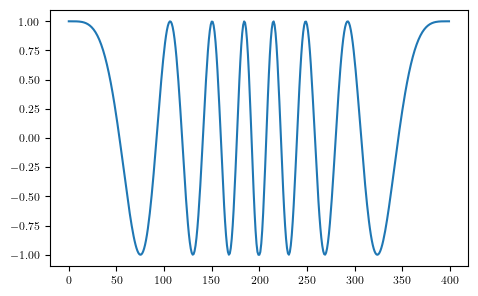

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Total points and time range
N = 200
t_start = 0
t_end = 7.0 * np.pi

# Generate increasing step sizes via quadratic scale
s = np.linspace(0, 1, N)         # Uniform spacing
s_curve = s**2                   # Quadratic growth
t = t_start + (t_end - t_start) * s_curve  # Map to time domain
t_flipped = t[::-1]

t_concat = np.concatenate((t, t_flipped))
xref_traj_2 = np.cos(t_concat)




In [109]:
# Put them in a dictionary with variable names
data_to_save = {
    "Y_T_MS": Y_T,
    "X0_T_MS": X0_T,
    "U_T_MS": U_T,
    "u_data_MS": u_data,
    "x_MS": x,
    "x_vals_MS": x_vals,
    "u_vals_MS": u_vals,
    "solve_times_MS": solve_times,
    "xref_traj_MS": xref_traj,
    "val_loss_MS": val_loss,
    "train_loss_MS": train_loss
    
}

# Save to a .mat file
savemat('MS_DeepONet_vdp.mat', data_to_save)

print("Arrays saved to 'MS_DeepONet_vdp.mat'")


Arrays saved to 'MS_DeepONet_vdp.mat'
